# 02 — Simulated Annealing: casas y hospitales

**Curso:** Inteligencia Artificial — Optimización

En este ejercicio usaremos el mismo problema de ubicación de hospitales del notebook de Hill Climbing. Así podremos comparar ambos algoritmos sobre el mismo espacio de estados, función de costo y vecindario.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## Objetivos

- implementar Simulated Annealing para un problema discreto;
- comprender la aceptación probabilística de soluciones peores;
- analizar el efecto de la temperatura y el enfriamiento;
- comparar Hill Climbing y Simulated Annealing sobre el mismo problema.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales.

El costo de una solución es la suma de la distancia de cada casa al hospital más cercano:

$$
J(H)=\sum_{c\in C}\min_{h\in H} d(c,h)
$$

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2))=|r_1-r_2|+|c_1-c_2|
$$

El objetivo es **minimizar** $J(H)$.

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [2]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(
        min(manhattan(house, hospital) for hospital in hospitals)
        for house in houses
    )


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        rows, cols = zip(*houses)
        ax.scatter(cols, rows, marker="s", s=110, label="Casas")

    if hospitals:
        rows, cols = zip(*hospitals)
        ax.scatter(cols, rows, marker="P", s=180, label="Hospitales")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f"Costo = {total_cost(houses, hospitals)}")
    plt.tight_layout()
    plt.show()

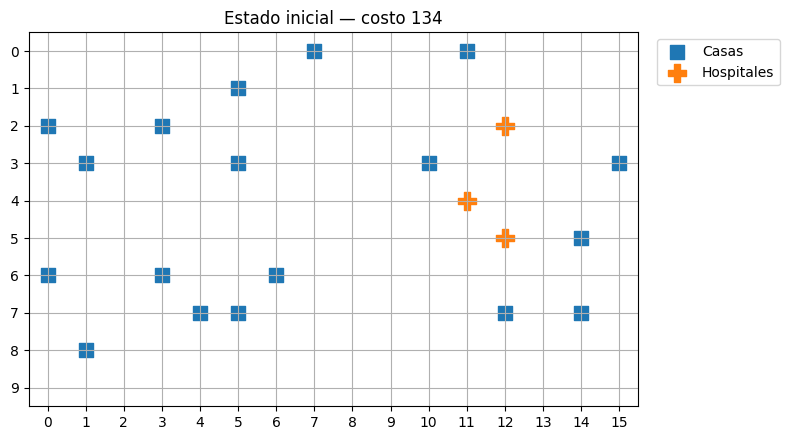

In [3]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [
    (row, col)
    for row in range(HEIGHT)
    for col in range(WIDTH)
]

houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(
    random.sample(available, NUM_HOSPITALS)
)

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    title=(
        "Estado inicial — costo "
        f"{total_cost(houses, initial_hospitals)}"
    ),
)

## 2. Vecindario

Un estado está formado por las posiciones de los hospitales.

Un vecino se obtiene moviendo **un hospital** una celda hacia arriba, abajo, izquierda o derecha, siempre que la nueva posición:

- esté dentro de la cuadrícula;
- no contenga una casa;
- no esté ocupada por otro hospital.

In [4]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (
                hospital[0] + dr,
                hospital[1] + dc,
            )

            if not (
                0 <= candidate[0] < height
                and 0 <= candidate[1] < width
            ):
                continue

            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors


neighbors = neighbors_of_state(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
)

print("Número de vecinos:", len(neighbors))
print("Costo actual:", total_cost(houses, initial_hospitals))
print(
    "Mejor costo vecino:",
    min(total_cost(houses, state) for state in neighbors),
)

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing como línea base

Hill Climbing siempre se mueve al mejor vecino disponible.

Si ningún vecino mejora el costo actual, se detiene.

Costo inicial: 134
Costo final: 62
Iteraciones: 13


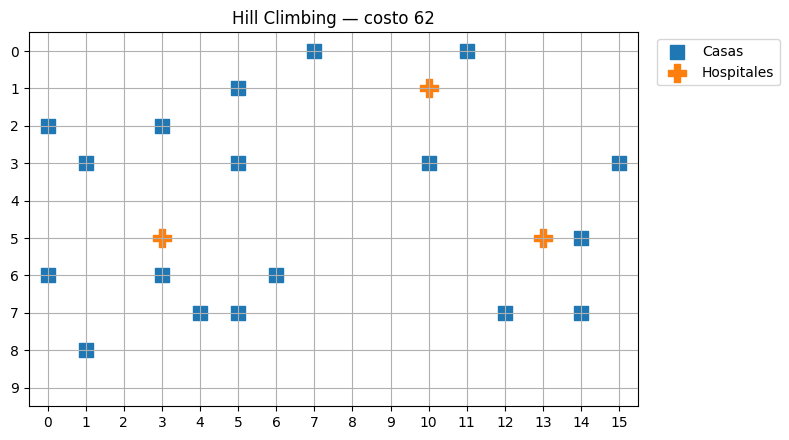

In [5]:
def hill_climbing(
    height,
    width,
    houses,
    initial_state,
    max_iterations=200,
    rng=None,
):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)

    history = [current_cost]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(
            height,
            width,
            houses,
            current,
        )

        if not neighbors:
            break

        costs = [
            total_cost(houses, neighbor)
            for neighbor in neighbors
        ]
        best_cost = min(costs)

        if best_cost >= current_cost:
            break

        best_neighbors = [
            neighbor
            for neighbor, cost in zip(neighbors, costs)
            if cost == best_cost
        ]

        current = set(rng.choice(best_neighbors))
        current_cost = best_cost
        history.append(current_cost)
        states.append(set(current))

    return current, history, states


hc_solution, hc_history, hc_states = hill_climbing(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    rng=random.Random(SEED),
)

print("Costo inicial:", hc_history[0])
print("Costo final:", hc_history[-1])
print("Iteraciones:", len(hc_history) - 1)

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    hc_solution,
    title=f"Hill Climbing — costo {hc_history[-1]}",
)

## 4. Regla de aceptación de Simulated Annealing

Sea:

$$
\Delta = J(H') - J(H)
$$

Como estamos minimizando:

- si $\Delta \leq 0$, el nuevo estado es igual o mejor y se acepta;
- si $\Delta > 0$, el nuevo estado es peor, pero puede aceptarse con probabilidad:

$$
P(\text{aceptar})=e^{-\Delta/T}
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más conservador.

In [6]:
def acceptance_probability(delta_cost, temperature):
    if delta_cost <= 0:
        return 1.0

    if temperature <= 0:
        return 0.0

    return math.exp(-delta_cost / temperature)


for temperature in [0.1, 1, 5, 20]:
    probability = acceptance_probability(
        delta_cost=3,
        temperature=temperature,
    )
    print(
        f"T={temperature:>4}: "
        f"P(aceptar un aumento de 3)={probability:.3f}"
    )

T= 0.1: P(aceptar un aumento de 3)=0.000
T=   1: P(aceptar un aumento de 3)=0.050
T=   5: P(aceptar un aumento de 3)=0.549
T=  20: P(aceptar un aumento de 3)=0.861


## 5. Implementación

En cada iteración:

1. generamos los vecinos;
2. seleccionamos **uno al azar**;
3. calculamos $\Delta$;
4. aplicamos la regla de aceptación;
5. reducimos la temperatura.

Costo inicial: 134
Mejor costo: 56
Iteraciones: 1500


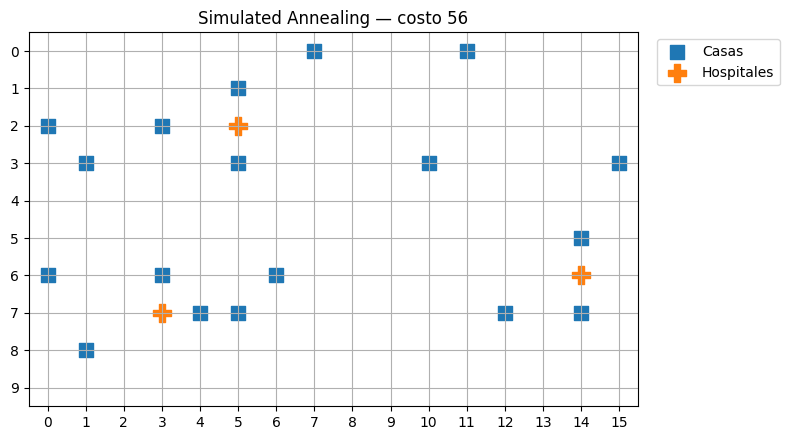

In [7]:
def simulated_annealing(
    height,
    width,
    houses,
    initial_state,
    iterations=1000,
    initial_temperature=20.0,
    cooling_rate=0.995,
    minimum_temperature=1e-3,
    rng=None,
):
    rng = rng or random.Random()

    current = set(initial_state)
    current_cost = total_cost(houses, current)

    best = set(current)
    best_cost = current_cost

    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        neighbors = neighbors_of_state(
            height,
            width,
            houses,
            current,
        )

        if not neighbors or temperature < minimum_temperature:
            break

        candidate = set(rng.choice(neighbors))
        candidate_cost = total_cost(houses, candidate)
        delta_cost = candidate_cost - current_cost

        probability = acceptance_probability(
            delta_cost,
            temperature,
        )
        accepted = rng.random() < probability

        if accepted:
            current = candidate
            current_cost = candidate_cost

            if current_cost < best_cost:
                best = set(current)
                best_cost = current_cost

        records.append({
            "iteration": iteration,
            "temperature": temperature,
            "current_cost": current_cost,
            "best_cost": best_cost,
            "delta_cost": delta_cost,
            "accepted": accepted,
        })

        temperature *= cooling_rate

    return best, records


sa_solution, sa_records = simulated_annealing(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    iterations=1500,
    initial_temperature=20,
    cooling_rate=0.995,
    rng=random.Random(SEED),
)

print("Costo inicial:", total_cost(houses, initial_hospitals))
print("Mejor costo:", total_cost(houses, sa_solution))
print("Iteraciones:", len(sa_records))

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    sa_solution,
    title=(
        "Simulated Annealing — costo "
        f"{total_cost(houses, sa_solution)}"
    ),
)

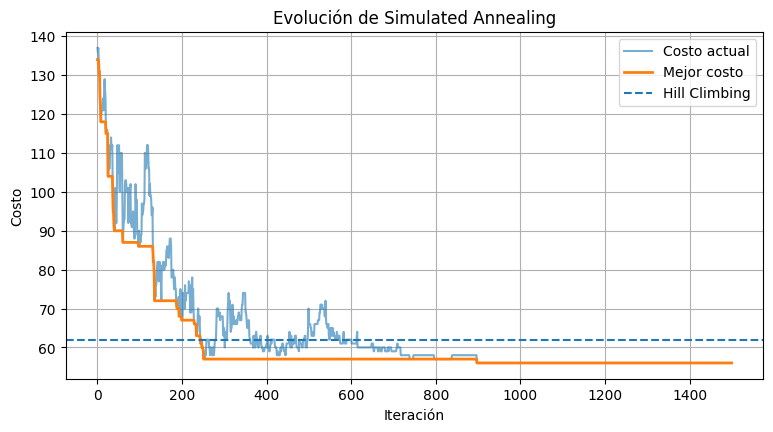

In [8]:
iterations = [record["iteration"] for record in sa_records]
current_costs = [record["current_cost"] for record in sa_records]
best_costs = [record["best_cost"] for record in sa_records]

plt.figure(figsize=(9, 4.5))
plt.plot(iterations, current_costs, alpha=0.6, label="Costo actual")
plt.plot(iterations, best_costs, linewidth=2, label="Mejor costo")
plt.axhline(
    hc_history[-1],
    linestyle="--",
    label="Hill Climbing",
)
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Evolución de Simulated Annealing")
plt.legend()
plt.grid(True)
plt.show()

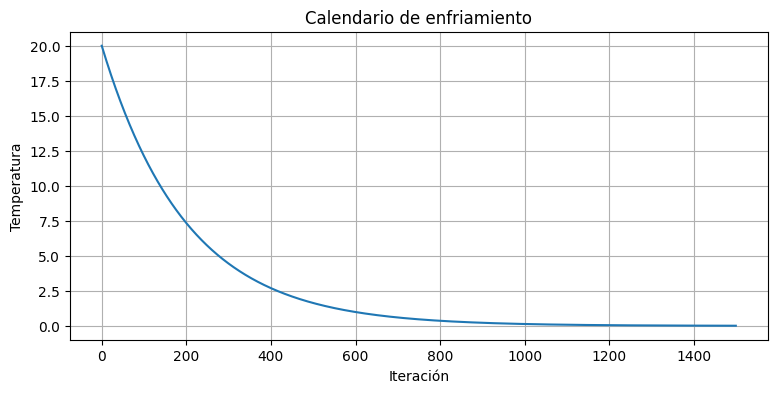

Porcentaje de movimientos aceptados: 36.2%


In [9]:
temperatures = [record["temperature"] for record in sa_records]
accepted = [record["accepted"] for record in sa_records]

plt.figure(figsize=(9, 4))
plt.plot(iterations, temperatures)
plt.xlabel("Iteración")
plt.ylabel("Temperatura")
plt.title("Calendario de enfriamiento")
plt.grid(True)
plt.show()

print(
    "Porcentaje de movimientos aceptados:",
    f"{100 * np.mean(accepted):.1f}%",
)

## 6. Comparación estadística

Una sola corrida puede ser engañosa. Ejecutaremos ambos algoritmos desde diferentes estados iniciales.

In [10]:
def random_initial_state(
    height,
    width,
    houses,
    num_hospitals,
    rng,
):
    cells = [
        (row, col)
        for row in range(height)
        for col in range(width)
        if (row, col) not in houses
    ]
    return set(rng.sample(cells, num_hospitals))


hc_results = []
sa_results = []

for seed in range(30):
    rng = random.Random(seed)
    start = random_initial_state(
        HEIGHT,
        WIDTH,
        houses,
        NUM_HOSPITALS,
        rng,
    )

    hc_solution_i, hc_history_i, _ = hill_climbing(
        HEIGHT,
        WIDTH,
        houses,
        start,
        rng=random.Random(seed),
    )

    sa_solution_i, _ = simulated_annealing(
        HEIGHT,
        WIDTH,
        houses,
        start,
        iterations=1200,
        initial_temperature=20,
        cooling_rate=0.995,
        rng=random.Random(seed),
    )

    hc_results.append(total_cost(houses, hc_solution_i))
    sa_results.append(total_cost(houses, sa_solution_i))

print("Hill Climbing — promedio:", np.mean(hc_results))
print("Simulated Annealing — promedio:", np.mean(sa_results))
print("Hill Climbing — mejor:", min(hc_results))
print("Simulated Annealing — mejor:", min(sa_results))

Hill Climbing — promedio: 72.2
Simulated Annealing — promedio: 56.333333333333336
Hill Climbing — mejor: 57
Simulated Annealing — mejor: 56


/tmp/ipykernel_502/4138087256.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


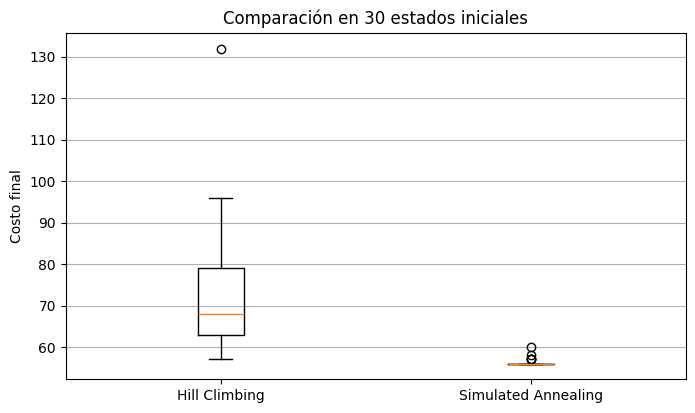

In [11]:
plt.figure(figsize=(8, 4.5))
plt.boxplot(
    [hc_results, sa_results],
    labels=["Hill Climbing", "Simulated Annealing"],
)
plt.ylabel("Costo final")
plt.title("Comparación en 30 estados iniciales")
plt.grid(True, axis="y")
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Compara:

$$
T_0\in\{0.1,1,5,20,100\}
$$

Para cada valor, ejecuta 20 corridas y registra:

- costo promedio;
- mejor costo;
- porcentaje de movimientos aceptados.

In [12]:
initial_temperatures = [0.1, 1, 5, 20, 100]
results = []

for initial_temperature in initial_temperatures:
    costs = []
    accepted_fracs = []

    for seed in range(20):
        rng = random.Random(seed)
        solution, records = simulated_annealing(
            HEIGHT,
            WIDTH,
            houses,
            initial_hospitals,
            iterations=1000,
            initial_temperature=initial_temperature,
            cooling_rate=0.995,
            rng=rng,
        )
        costs.append(total_cost(houses, solution))
        accepted_fracs.append(np.mean([record["accepted"] for record in records]))

    results.append({
        "initial_temperature": initial_temperature,
        "mean_cost": float(np.mean(costs)),
        "best_cost": int(min(costs)),
        "pct_accepted": 100 * float(np.mean(accepted_fracs)),
    })

print(f"{'T0':>6} | {'costo medio':>12} | {'mejor costo':>12} | {'% aceptados':>12}")
for row in results:
    print(f"{row['initial_temperature']:>6} | {row['mean_cost']:>12.2f} | "
          f"{row['best_cost']:>12} | {row['pct_accepted']:>11.1f}%")

results


    T0 |  costo medio |  mejor costo |  % aceptados
   0.1 |        61.85 |           56 |        17.5%
     1 |        60.20 |           56 |        24.7%
     5 |        57.05 |           56 |        45.6%
    20 |        56.30 |           56 |        60.5%
   100 |        56.65 |           56 |        80.1%


[{'initial_temperature': 0.1,
  'mean_cost': 61.85,
  'best_cost': 56,
  'pct_accepted': 17.53536452665941},
 {'initial_temperature': 1,
  'mean_cost': 60.2,
  'best_cost': 56,
  'pct_accepted': 24.705},
 {'initial_temperature': 5,
  'mean_cost': 57.05,
  'best_cost': 56,
  'pct_accepted': 45.550000000000004},
 {'initial_temperature': 20,
  'mean_cost': 56.3,
  'best_cost': 56,
  'pct_accepted': 60.519999999999996},
 {'initial_temperature': 100,
  'mean_cost': 56.65,
  'best_cost': 56,
  'pct_accepted': 80.08999999999999}]

### Actividad 2 — Enfriamiento

Compara:

$$
\alpha\in\{0.90,0.95,0.98,0.995,0.999\}
$$

¿Qué ocurre cuando la temperatura disminuye demasiado rápido? ¿Qué ocurre cuando disminuye demasiado lento?

  alpha |  costo medio |      std
    0.9 |        68.55 |     6.90
   0.95 |        63.35 |     5.82
   0.98 |        60.75 |     5.25
  0.995 |        56.30 |     0.95
  0.999 |        57.20 |     1.36


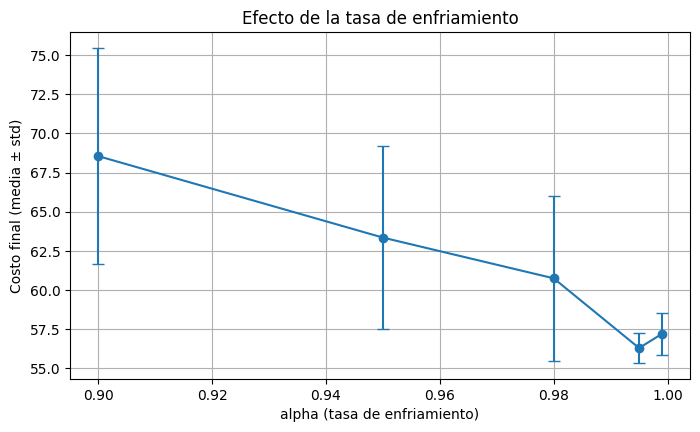

In [13]:
cooling_rates = [0.90, 0.95, 0.98, 0.995, 0.999]
cooling_results = []

for alpha in cooling_rates:
    costs = []

    for seed in range(20):
        rng = random.Random(seed)
        solution, _ = simulated_annealing(
            HEIGHT,
            WIDTH,
            houses,
            initial_hospitals,
            iterations=1500,
            initial_temperature=20,
            cooling_rate=alpha,
            rng=rng,
        )
        costs.append(total_cost(houses, solution))

    cooling_results.append({
        "alpha": alpha,
        "mean_cost": float(np.mean(costs)),
        "std_cost": float(np.std(costs)),
    })

print(f"{'alpha':>7} | {'costo medio':>12} | {'std':>8}")
for row in cooling_results:
    print(f"{row['alpha']:>7} | {row['mean_cost']:>12.2f} | {row['std_cost']:>8.2f}")

plt.figure(figsize=(8, 4.5))
plt.errorbar(
    [r["alpha"] for r in cooling_results],
    [r["mean_cost"] for r in cooling_results],
    yerr=[r["std_cost"] for r in cooling_results],
    marker="o",
    capsize=4,
)
plt.xlabel("alpha (tasa de enfriamiento)")
plt.ylabel("Costo final (media ± std)")
plt.title("Efecto de la tasa de enfriamiento")
plt.grid(True)
plt.show()


**Respuesta — Actividad 2:**

Con `alpha` bajo (por ejemplo 0.90), la temperatura cae a casi cero en muy pocas iteraciones. A partir de ahí, `acceptance_probability` devuelve prácticamente 0 para cualquier `delta_cost > 0`, así que el algoritmo deja de aceptar movimientos que empeoran la solución — se comporta como Hill Climbing desde muy temprano, y como además elige un vecino al azar (no el mejor), puede quedarse atrapado en un óptimo local peor que el que encontraría Hill Climbing puro.

Con `alpha` alto (cercano a 1, por ejemplo 0.999), la temperatura se mantiene alta durante más iteraciones, dando más oportunidades de escapar de óptimos locales. El costo, en promedio, es menor con `alpha` altos. La contrapartida es que necesita más iteraciones para "enfriarse" y converger a una solución estable; con un número fijo de iteraciones (como aquí, 1500), un `alpha` demasiado alto puede no alcanzar a converger del todo.

### Actividad 3 — Comparación justa

Para 50 estados iniciales:

1. ejecuta Hill Climbing;
2. ejecuta Simulated Annealing desde el mismo estado;
3. cuenta cuántas veces gana cada algoritmo;
4. compara el costo promedio.

In [14]:
wins = {
    "Hill Climbing": 0,
    "Simulated Annealing": 0,
    "Empate": 0,
}

hc_costs_fair = []
sa_costs_fair = []

for seed in range(50):
    rng = random.Random(seed)
    start = random_initial_state(
        HEIGHT,
        WIDTH,
        houses,
        NUM_HOSPITALS,
        rng,
    )

    hc_solution_i, hc_history_i, _ = hill_climbing(
        HEIGHT,
        WIDTH,
        houses,
        start,
        rng=random.Random(seed),
    )

    sa_solution_i, _ = simulated_annealing(
        HEIGHT,
        WIDTH,
        houses,
        start,
        iterations=1200,
        initial_temperature=20,
        cooling_rate=0.995,
        rng=random.Random(seed),
    )

    hc_cost = total_cost(houses, hc_solution_i)
    sa_cost = total_cost(houses, sa_solution_i)
    hc_costs_fair.append(hc_cost)
    sa_costs_fair.append(sa_cost)

    if hc_cost < sa_cost:
        wins["Hill Climbing"] += 1
    elif sa_cost < hc_cost:
        wins["Simulated Annealing"] += 1
    else:
        wins["Empate"] += 1

print("Resultados (50 estados iniciales):", wins)
print(f"Hill Climbing        — costo medio: {np.mean(hc_costs_fair):.2f}")
print(f"Simulated Annealing   — costo medio: {np.mean(sa_costs_fair):.2f}")


Resultados (50 estados iniciales): {'Hill Climbing': 0, 'Simulated Annealing': 48, 'Empate': 2}
Hill Climbing        — costo medio: 70.70
Simulated Annealing   — costo medio: 56.40


## Preguntas de cierre

1. ¿Por qué Simulated Annealing puede aceptar un hospital en una posición que aumenta temporalmente el costo?
2. ¿Qué función cumple la temperatura?
3. ¿Por qué debemos conservar la mejor solución observada y no solamente el estado final?
4. ¿Simulated Annealing garantiza encontrar el óptimo global con un número finito de iteraciones?
5. ¿Qué diferencia fundamental hay entre escoger el mejor vecino y escoger un vecino al azar?

### Respuestas — preguntas de cierre

1. **¿Por qué Simulated Annealing puede aceptar un hospital en una posición que aumenta temporalmente el costo?** Porque su regla de aceptación no exige que el candidato sea mejor: cuando `delta_cost > 0` (empeora), lo acepta con probabilidad `exp(-delta_cost/T)`, que es mayor que cero. Esto le permite "salir" de un óptimo local temporalmente, atravesando soluciones peores, para eventualmente llegar a una región del espacio de búsqueda con un costo aún menor que el óptimo local del que partió.

2. **¿Qué función cumple la temperatura?** Controla el balance entre exploración y explotación. Con `T` alta, `exp(-delta_cost/T)` es cercano a 1 incluso para `delta_cost` grandes, así que el algoritmo acepta casi cualquier movimiento (explora ampliamente el espacio de estados). A medida que `T` baja, esa probabilidad se acerca a 0 para empeoras, y el algoritmo se vuelve cada vez más selectivo (explota/refina la mejor zona ya encontrada).

3. **¿Por qué debemos conservar la mejor solución observada y no solamente el estado final?** Porque el estado actual puede empeorar temporalmente durante la fase exploratoria (es justo lo que permite escapar de óptimos locales), así que en el momento en que termina la ejecución, el estado actual podría ser peor que otro que sí se visitó en el camino. Guardar `best` por separado asegura no perder la mejor solución encontrada durante todo el proceso.

4. **¿Simulated Annealing garantiza encontrar el óptimo global con un número finito de iteraciones?** No. La convergencia teórica al óptimo global solo está demostrada bajo un enfriamiento infinitamente lento (número infinito de iteraciones). Con presupuesto finito, como en la práctica, puede terminar en un óptimo local — aunque, gracias a la aceptación probabilística, tiene mayor probabilidad de escapar de él que Hill Climbing.

5. **¿Qué diferencia fundamental hay entre escoger el mejor vecino y escoger un vecino al azar?** Hill Climbing evalúa **todos** los vecinos y se mueve determinísticamente al mejor (codicioso): converge rápido, pero se detiene apenas ningún vecino mejora, quedando atrapado en el primer óptimo local. Simulated Annealing elige **un** vecino al azar y decide aceptarlo o no según la regla probabilística, sin garantizar que sea el mejor disponible — es menos eficiente por iteración, pero esa aleatoriedad es precisamente lo que le da la capacidad de explorar más ampliamente y escapar de óptimos locales.